In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("customer_sales_cleaned (1).csv")

df.head()

,Customer_ID,Name,Age,Gender,City,Product,Category,Purchase_Amount,Quantity,Payment_Mode,Purchase_Date,Email,Email_Status,Total_Amount,Customer_Type
0,101,Rahul,22.000000,Male,Hyderabad,Laptop,Electronics,55000,1,UPI,12-01-2025,rahul@gmail.com,Valid,55000,Premium
1,102,Ayesha,30.230769,Female,Bangalore,Phone,Electronics,25000,1,Cash,12-01-2025,ayesha@gmail.com,Valid,25000,Regular
2,103,Vikram,28.000000,Male,Chennai,Shirt,Fashion,4750,2,Card,18-01-2025,vikram@gmail.com,Valid,9500,Regular
3,104,Neha,24.000000,Female,Unknown,Shoes,Fashion,2200,1,UPI,12-01-2025,neha@gmail.com,Valid,2200,Regular
4,105,Arjun,35.000000,Male,Delhi,Watch,Accessories,4500,1,Card,22-01-2025,arjun@gmail.com,Valid,4500,Regular


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      15 non-null     int64  
 1   Name             15 non-null     object 
 2   Age              15 non-null     float64
 3   Gender           15 non-null     object 
 4   City             15 non-null     object 
 5   Product          15 non-null     object 
 6   Category         15 non-null     object 
 7   Purchase_Amount  15 non-null     int64  
 8   Quantity         15 non-null     int64  
 9   Payment_Mode     15 non-null     object 
 10  Purchase_Date    15 non-null     object 
 11  Email            15 non-null     object 
 12  Email_Status     15 non-null     object 
 13  Total_Amount     15 non-null     int64  
 14  Customer_Type    15 non-null     object 
dtypes: float64(1), int64(4), object(10)
memory usage: 1.9+ KB


In [8]:
df.describe()

,Customer_ID,Age,Purchase_Amount,Quantity,Total_Amount
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,108.000000,30.230769,17936.666667,1.333333,18946.666667
std,4.472136,6.645663,20914.404355,0.617213,20254.307008
min,101.000000,22.000000,1500.000000,1.000000,1500.000000
25%,104.500000,25.500000,2600.000000,1.000000,3550.000000
50%,108.000000,29.000000,4750.000000,1.000000,9500.000000
75%,111.500000,33.000000,29500.000000,1.500000,29500.000000
max,115.000000,45.000000,62000.000000,3.000000,62000.000000


In [9]:
#Check Total sales
total_sales = df["Total_Amount"].sum()

print("Total Sales:", total_sales)

Total Sales: 284200


In [10]:
#Top selling products
top_products = df.groupby("Product")["Total_Amount"].sum().sort_values(ascending=False)

print(top_products)

Product
Laptop     117000
Phone       52000
TV          40000
Fridge      32000
Shirt       14900
Watch       14500
Shoes        3700
Bag          3600
Handbag      3500
Jeans        3000
Name: Total_Amount, dtype: int64


In [11]:
#sales by category
category_sales = df.groupby("Category")["Total_Amount"].sum()

print(category_sales)

Category
Accessories     21600
Electronics    241000
Fashion         21600
Name: Total_Amount, dtype: int64


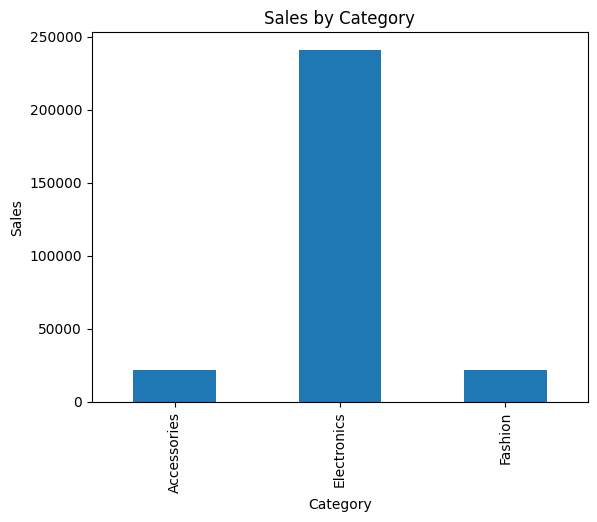

In [12]:
#Visualization 1-Bar chart
category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

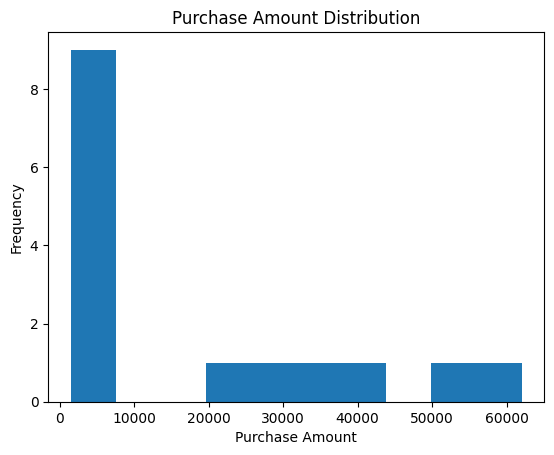

In [13]:
#visualization 2-Histogram
plt.hist(df["Purchase_Amount"], bins=10)

plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")

plt.show()

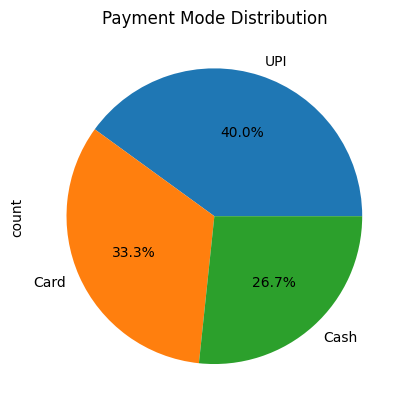

In [14]:
#visualization 3-pie chart
payment_mode = df["Payment_Mode"].value_counts()

payment_mode.plot(kind="pie", autopct="%1.1f%%")

plt.title("Payment Mode Distribution")

plt.show()

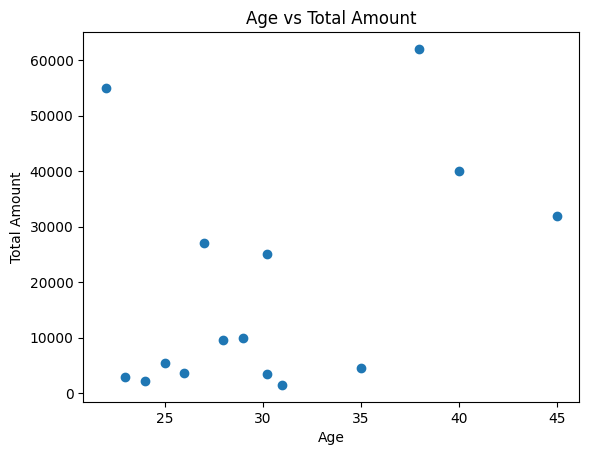

In [15]:
#visualization 4-scatter plot
plt.scatter(df["Age"], df["Total_Amount"])

plt.title("Age vs Total Amount")
plt.xlabel("Age")
plt.ylabel("Total Amount")

plt.show()

In [16]:
#correlation analysis
correlation = df[["Age", "Purchase_Amount", "Quantity", "Total_Amount"]].corr()

print(correlation)

                      Age  Purchase_Amount  Quantity  Total_Amount
Age              1.000000         0.389847 -0.316131      0.379630
Purchase_Amount  0.389847         1.000000 -0.412422      0.996429
Quantity        -0.316131        -0.412422  1.000000     -0.347585
Total_Amount     0.379630         0.996429 -0.347585      1.000000


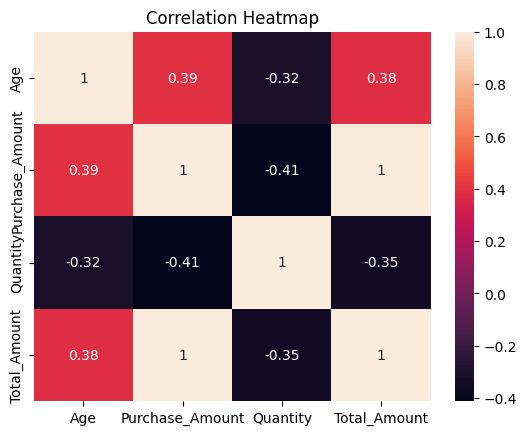

In [17]:
#visualization 5-heatmap
import seaborn as sns

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
df.to_csv("eda_processed_dataset.csv", index=False)

In [ ]:
from google.colab import files
files.download("eda_processed_dataset.csv")